# Full cleaning pipeline and EDA

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('dirty_cafe_sales.csv')

In [3]:
missing_values = ['nan', 'ERROR', 'UNKNOWN']

In [4]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [6]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [7]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
df['Item'].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str

### Handling missing value

- first df has null values + some missing str that need to replace eg.(nan, ERROR)

In [9]:
cat_cols = df.select_dtypes(include='str').columns

In [10]:
df[cat_cols] = df[cat_cols].replace(missing_values, np.nan).fillna('Unknown')

In [11]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,Unknown,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Unknown,3,Unknown,3.0,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3,Unknown,3.0,Digital Wallet,Unknown,2023-12-02


In [12]:
df['Item'].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'Unknown',
 'Sandwich',    'Juice',      'Tea']
Length: 9, dtype: str

/ replace all missing data to 'Unknown' hence we dont have proper info

# Converting column to numeric

In [13]:
cols = ['Quantity','Price Per Unit','Total Spent']

In [14]:
df[cols] = df[cols].replace(missing_values, np.nan)

In [15]:
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [16]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Unknown,3.0,NaN,3.0,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,Unknown,2023-12-02


In [17]:
df['Quantity'].unique()

array([ 2.,  4.,  5.,  3.,  1., nan])

# filling non values by mean

In [18]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())

In [19]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())

In [20]:
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].mean())

In [21]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.924352,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.000000,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Unknown,3.0,2.949984,3.000000,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949984,3.000000,Digital Wallet,Unknown,2023-12-02


### to datetime

In [22]:
# df['Transaction Date'] = df['Transaction Date'].replace('Unknown', np.nan).astype('datetime64[ns]')

In [23]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [24]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.924352,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.000000,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Unknown,3.0,2.949984,3.000000,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949984,3.000000,Digital Wallet,Unknown,2023-12-02


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  str           
 1   Item              10000 non-null  str           
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  str           
 6   Location          10000 non-null  str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 625.1 KB


# Fill missing dates with nearby records.


In [26]:
df['Transaction Date'].iloc[100:110]

100   2023-10-30
101   2023-10-28
102   2023-12-15
103          NaT
104          NaT
105   2023-02-25
106   2023-04-03
107   2023-10-08
108   2023-12-28
109   2023-08-30
Name: Transaction Date, dtype: datetime64[us]

In [27]:
df['Transaction Date'] = df['Transaction Date'].ffill()

In [74]:
df['Transaction Date'][100:120]

100   2023-10-30
101   2023-10-28
102   2023-12-15
103   2023-12-15
104   2023-12-15
105   2023-02-25
106   2023-04-03
107   2023-10-08
108   2023-12-28
109   2023-08-30
110   2023-02-03
111   2023-09-12
112   2023-04-27
113   2023-05-04
114   2023-02-21
115   2023-02-21
116   2023-03-16
117   2023-01-10
118   2023-02-06
119   2023-02-24
Name: Transaction Date, dtype: datetime64[us]

In [29]:
df['Transaction Date'].iloc[100:110]

100   2023-10-30
101   2023-10-28
102   2023-12-15
103   2023-12-15
104   2023-12-15
105   2023-02-25
106   2023-04-03
107   2023-10-08
108   2023-12-28
109   2023-08-30
Name: Transaction Date, dtype: datetime64[us]

In [30]:
df.loc[1,'Transaction Date'].day_name()

'Tuesday'

# Correcting price per unit and their price spent

### menu items with their respective price ranges:

In [31]:
price_map = {
    'Coffee' : 2.0,
    'Tea' :	1.5,
    'Sandwich' : 4.0,
    'Salad' : 5.0,
    'Cake' : 3.0,
    'Cookie' : 1.0,
    'Smoothie' : 4.0,
    'Juice' : 3.0
}

In [32]:
df['Price Per Unit'] = df['Item'].map(price_map).fillna(df['Price Per Unit'])

In [33]:
df['Total Spent'] = np.where(
    df['Total Spent'] != df['Quantity'] * df['Price Per Unit'],
    df['Quantity'] * df['Price Per Unit'],
    df['Total Spent']

)

In [34]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,4.000000,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.000000,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Unknown,3.0,2.949984,8.849952,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.000000,3.000000,Digital Wallet,Unknown,2023-12-02


/ checking and correcting invalid multiplication of total spent

In [42]:
df['Day of the Week'] = df['Transaction Date'].dt.day_name()

In [51]:
df['Transaction Month'] = df['Transaction Date'].dt.month_name()

In [52]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day of the Week,Transaction Month
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08,Friday,September
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-store,2023-05-16,Tuesday,May
2,TXN_4271903,Cookie,4.0,1.000000,4.000000,Credit Card,In-store,2023-07-19,Wednesday,July
3,TXN_7034554,Salad,2.0,5.000000,10.000000,Unknown,Unknown,2023-04-27,Thursday,April
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-store,2023-06-11,Sunday,June
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,Unknown,Unknown,2023-08-30,Wednesday,August
9996,TXN_9659401,Unknown,3.0,2.949984,8.849952,Digital Wallet,Unknown,2023-06-02,Friday,June
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,Unknown,2023-03-02,Thursday,March
9998,TXN_7695629,Cookie,3.0,1.000000,3.000000,Digital Wallet,Unknown,2023-12-02,Saturday,December


# 4 EDA Questions

### 1. What items sells the most by Quantity?

In [56]:
df.groupby('Item')['Quantity'].sum()

Item
Cake        3468.309316
Coffee      3552.736267
Cookie      3250.508560
Juice       3515.337780
Salad       3470.508560
Sandwich    3429.736267
Smoothie    3354.252389
Tea         3320.565487
Unknown     2922.679340
Name: Quantity, dtype: float64

- `Coffee` is the most selling item in Quantity

### 2.  What's the Monthly revenue trend across the year?

In [57]:
df['month'] = df['Transaction Date'].dt.month

In [58]:
monthly_revenue = df.groupby('month')['Total Spent'].sum()

In [59]:
monthly_revenue

month
1     7593.384434
2     6933.732579
3     7662.801437
4     7593.090589
5     7309.462654
6     7714.401217
7     7288.698527
8     7428.829455
9     7139.802005
10    7749.779224
11    7323.619955
12    7649.376444
Name: Total Spent, dtype: float64

<Axes: xlabel='month'>

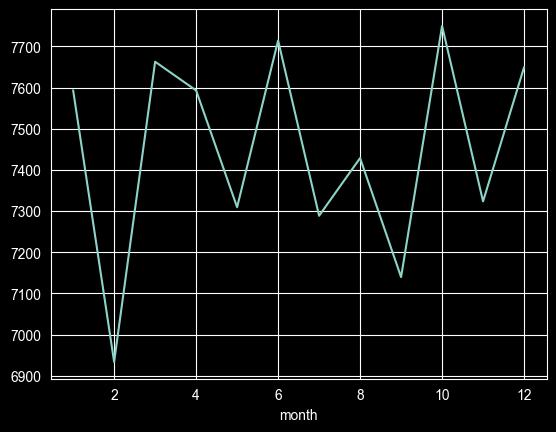

In [63]:
monthly_revenue.plot()

### 3. Which payments mode dominates, does it vary by location?

In [64]:
df['Payment Method'].value_counts()

Payment Method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

` does it Vary by location?`

In [68]:
df.groupby('Location')['Payment Method'].value_counts()

Location  Payment Method
In-store  Unknown            939
          Cash               702
          Digital Wallet     695
          Credit Card        681
Takeaway  Unknown            945
          Digital Wallet     744
          Credit Card        669
          Cash               664
Unknown   Unknown           1294
          Credit Card        923
          Cash               892
          Digital Wallet     852
Name: count, dtype: int64

### 4. What the average spend per Transaction by item?

In [70]:
df.groupby('Item')['Total Spent'].mean()

Item
Cake         9.135143
Coffee       6.099118
Cookie       2.976656
Juice        9.005989
Salad       15.115455
Sandwich    12.129925
Smoothie    12.241797
Tea          4.573782
Unknown      8.886182
Name: Total Spent, dtype: float64

# Insights

- Coffee and Juice are the most frequently purchased items, which suggests customers lean more toward beverages than food items.
- A large number of transactions are marked as “Unknown” payment method, so it’s hard to draw any solid conclusion about how customers prefer to pay. This looks more like a data recording issue than an actual behavior pattern.